# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2 # have functions that can store the images as arrays.
import numpy as np # where we can deal with arrays
from PIL import Image # store the img as regular img.
from skimage import data # python img library, have functions like cv2(open, resize, etc...). and for the data it gives as data.
import matplotlib.pyplot as plt # help in graphing and img presention

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).
- we will take downsampling,, where we: the process of reducing the sample rate, resolution, or number of data points in a dataset, signal, or image.

In [2]:
def sample_image(image, factor):
    """Downsamples the image by the given factor.""" # divided by the given factor by 2
    height, width = image.shape[:2]
    sampled_image = cv2.resize( ## cv2 help us to resize.. what is interpolation? a mathematical method used
                                 #to estimate unknown values that lie between known data points
        image,
        (max(1, width // factor), max(1, height // factor)),
        interpolation=cv2.INTER_NEAREST
    )
    return sampled_image


def quantize_image(image, levels):
    """Reduces a uint8 grayscale image to the requested number of intensity levels."""
    if not 2 <= levels <= 256:
        raise ValueError("levels must be between 2 and 256")

    # Map [0, 255] -> [0, levels-1] -> [0, 255]
    quantized = np.round(image.astype(np.float32) * (levels - 1) / 255.0)
    quantized = np.round(quantized * 255.0 / (levels - 1))
    return quantized.astype(np.uint8)


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray', vmin=0, vmax=255)
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray', vmin=0, vmax=255)
    plt.title('Quantized Image'), plt.axis('off')
    plt.tight_layout()
    plt.show()


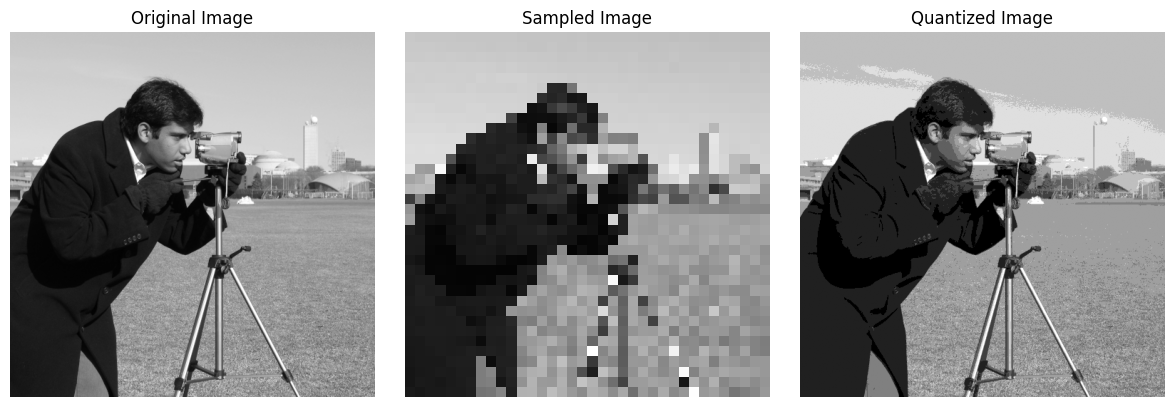

In [3]:
original_image = data.camera()

sampling_factor = 14 # كان نبغى نصغر الصوره ١٤ مره
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels) # the continuous range of brightness or color values is reduced to a smaller, fixed set of discrete levels.

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

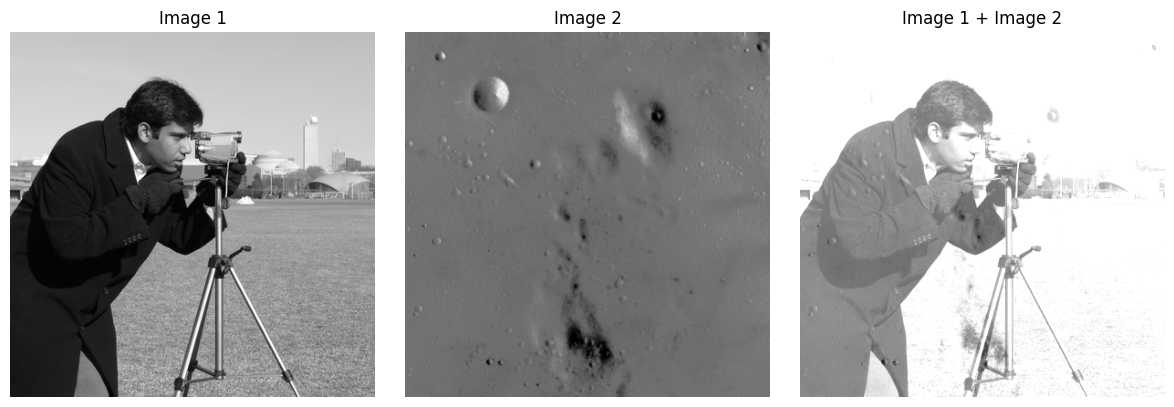

In [4]:
img1 = Image.fromarray(data.camera()) #transfare from array to img.
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS) #resize the photo
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1, dtype=np.uint8) #
im2arr = np.asarray(img2, dtype=np.uint8)

# Saturating addition avoids uint8 overflow/wrap-around.
addition = cv2.add(im1arr, im2arr)
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray', vmin=0, vmax=255), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray', vmin=0, vmax=255), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray', vmin=0, vmax=255), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.tight_layout()
plt.show()


---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

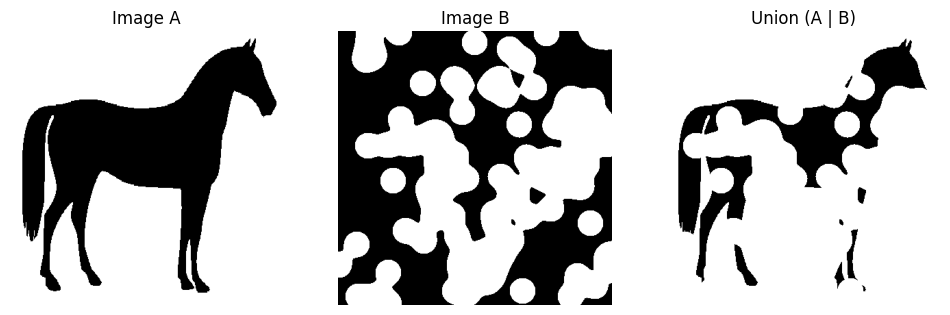

In [5]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

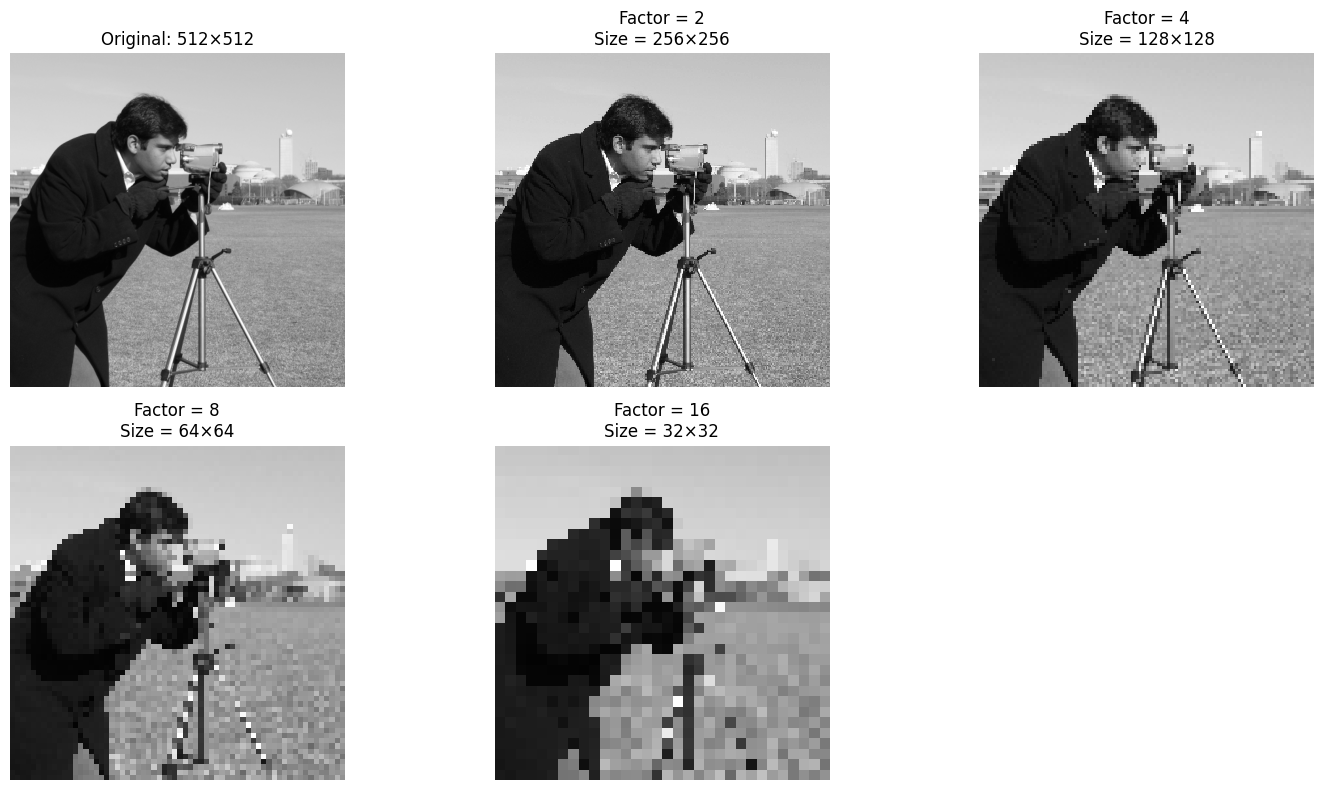

Observation:
As the sampling factor increases, fewer pixels are retained. Spatial resolution decreases, so the image loses fine details and appears more pixelated.


In [6]:
sampling_factors = [2, 4, 8, 16]

plt.figure(figsize=(15, 8))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(original_image, cmap='gray', vmin=0, vmax=255)
plt.title(f'Original: {original_image.shape[1]}×{original_image.shape[0]}')
plt.axis('off')

# Different sampling factors
for i, factor in enumerate(sampling_factors, start=2):
    sampled = sample_image(original_image, factor)
    plt.subplot(2, 3, i)
    plt.imshow(sampled, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    plt.title(f'Factor = {factor}\nSize = {sampled.shape[1]}×{sampled.shape[0]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Observation:")
print("As the sampling factor increases, fewer pixels are retained. Spatial resolution decreases, so the image loses fine details and appears more pixelated.")


### 1b) Effect of quantization levels (intensity resolution)

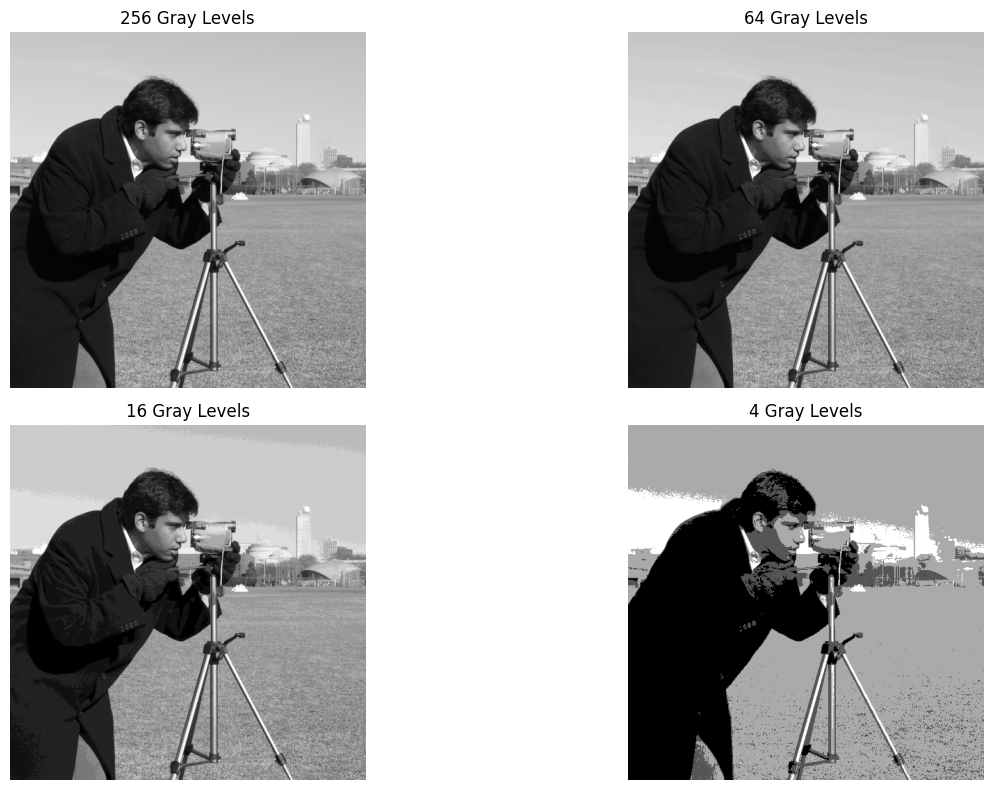

Observation:
As the number of quantization levels decreases, intensity resolution decreases. Smooth gray transitions are replaced by visible bands (false contouring).


In [7]:
quantization_levels_list = [256, 64, 16, 4]

plt.figure(figsize=(15, 8))

for i, levels in enumerate(quantization_levels_list, start=1):
    quantized = quantize_image(original_image, levels)
    plt.subplot(2, 2, i)
    plt.imshow(quantized, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{levels} Gray Levels')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Observation:")
print("As the number of quantization levels decreases, intensity resolution decreases. Smooth gray transitions are replaced by visible bands (false contouring).")


---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

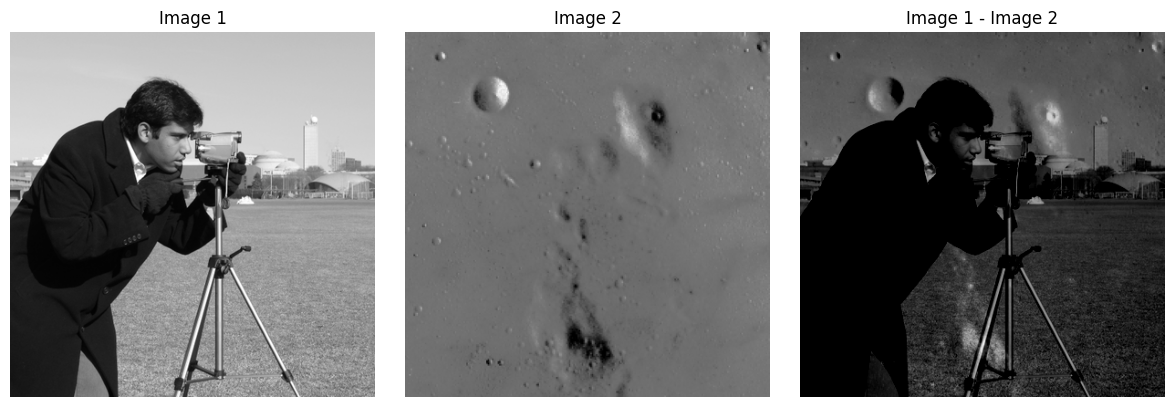

In [8]:
# Use the same two 400×400 grayscale images from Section 2.
# cv2.subtract performs saturated subtraction: negative values become 0.
subtraction = cv2.subtract(im1arr, im2arr)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(im1arr, cmap='gray', vmin=0, vmax=255), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(im2arr, cmap='gray', vmin=0, vmax=255), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(subtraction, cmap='gray', vmin=0, vmax=255), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.tight_layout()
plt.show()


### 2b) Add image with constant value 175

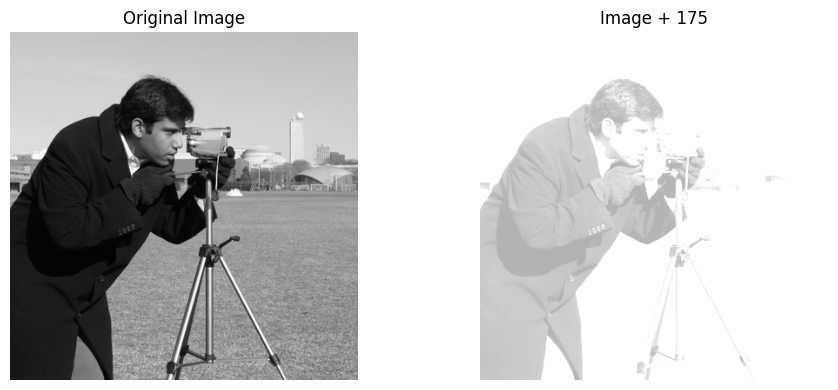

Adding 175 increases image brightness. Pixel values greater than 255 are clipped to 255.


In [9]:
constant = 175

# Saturating addition clips values above 255 instead of wrapping around.
added_constant = cv2.add(im1arr, np.full_like(im1arr, constant, dtype=np.uint8))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(im1arr, cmap='gray', vmin=0, vmax=255), plt.title('Original Image'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(added_constant, cmap='gray', vmin=0, vmax=255), plt.title('Image + 175'), plt.axis('off')
plt.tight_layout()
plt.show()

print("Adding 175 increases image brightness. Pixel values greater than 255 are clipped to 255.")


### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

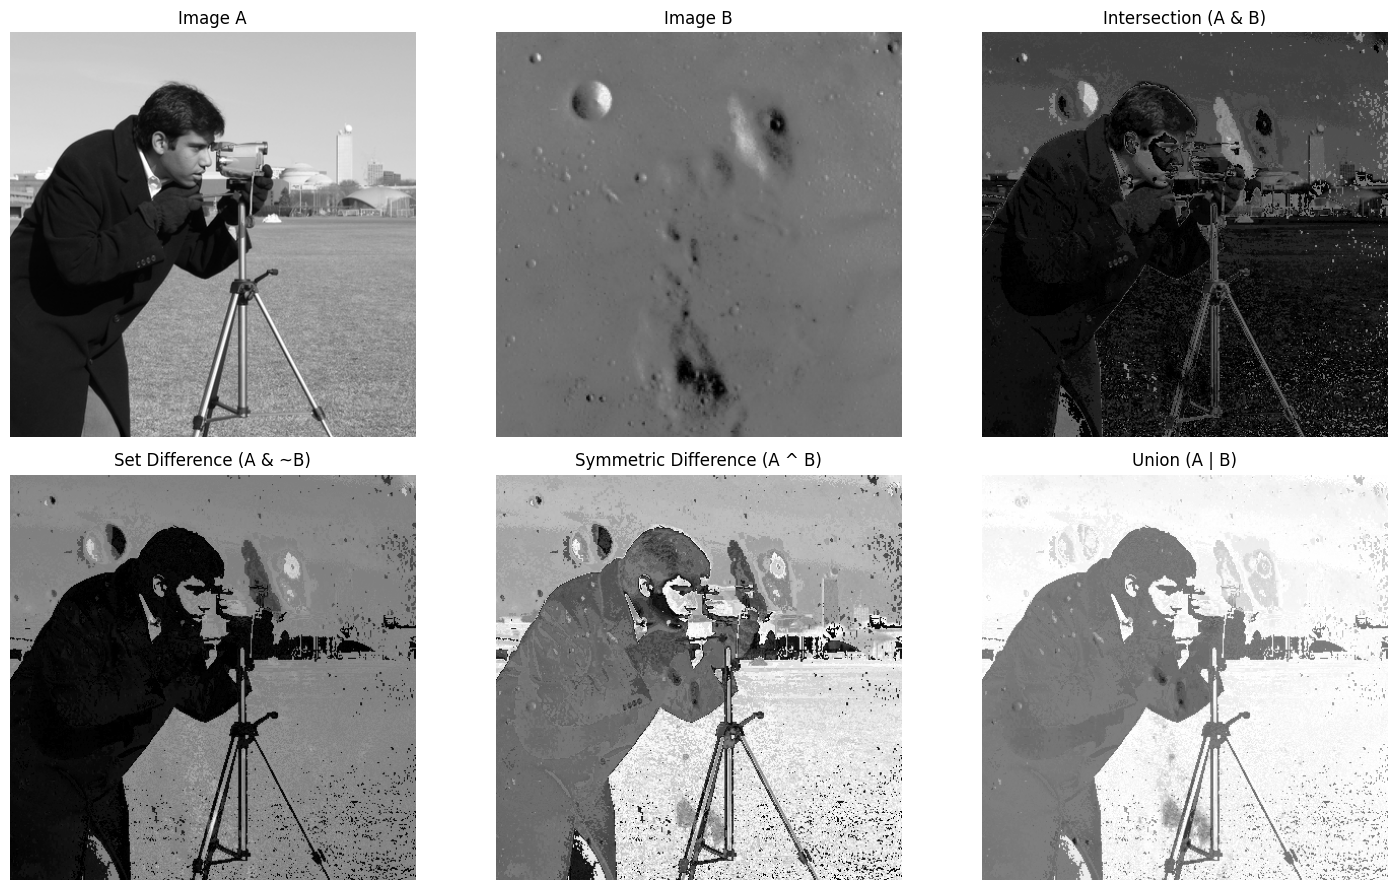

Set-operation summary:
Intersection keeps bits present in both images.
Set difference keeps bits present in A but not in B.
Symmetric difference keeps bits that differ between A and B.
Union keeps bits present in either image.


In [10]:
# Use two grayscale uint8 images of the same size.
A = np.asarray(Image.fromarray(data.camera()).resize(new_size, Image.Resampling.LANCZOS), dtype=np.uint8)
B = np.asarray(Image.fromarray(data.moon()).resize(new_size, Image.Resampling.LANCZOS), dtype=np.uint8)

intersection = cv2.bitwise_and(A, B)          # A & B
set_difference = cv2.bitwise_and(A, cv2.bitwise_not(B))  # A & ~B
symmetric_difference = cv2.bitwise_xor(A, B) # A ^ B
union = cv2.bitwise_or(A, B)                  # A | B (extra)

operations = [
    ('Image A', A),
    ('Image B', B),
    ('Intersection (A & B)', intersection),
    ('Set Difference (A & ~B)', set_difference),
    ('Symmetric Difference (A ^ B)', symmetric_difference),
    ('Union (A | B)', union),
]

plt.figure(figsize=(15, 9))
for i, (title, image) in enumerate(operations, start=1):
    plt.subplot(2, 3, i)
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Set-operation summary:")
print("Intersection keeps bits present in both images.")
print("Set difference keeps bits present in A but not in B.")
print("Symmetric difference keeps bits that differ between A and B.")
print("Union keeps bits present in either image.")
